12E1.  What is the difference between an ordered categorical variable and an unordered one? Define and then give an example of each.

**AI Prompt**

in ordered categorical one order might contain some information (that one level is higher than the other one, like education variable could be ordered). unordered does not have a natural ordering like colors usually

**AI Response**

You've got the right idea! Let me help you refine that understanding a bit.

**Ordered categorical variables** (also called ordinal variables) have categories with a meaningful ranking or sequence. The order tells us something important - one level is "higher," "better," or "more" than another.

**Unordered categorical variables** (also called nominal variables) have categories that are just different labels with no natural ranking.

Your education example is perfect for ordered categorical! Can you think of what the specific levels might be (like what would come first, second, third, etc.)?

And for unordered categorical, colors is a great example. Can you think of another example of an unordered categorical variable?



12E2.  What kind of link function does an ordered logistic regression employ? How does it differ from an ordinary logit link?

**AI Prompt**

cumulkative link function. this takes cmuluative probability that response falls below or up to certain cutpoint

**AI Response**

You're on the right track! Yes, ordered logistic regression uses a **cumulative link function**.

Your understanding is correct - it works with cumulative probabilities. Specifically, it models the probability that the response falls *at or below* a certain category level.

Can you explain how this differs from what an ordinary logit link does? What does a regular logistic regression model in terms of probabilities?



**AI Prompt**

it just returns log odds. from which probability could be calculated

**AI Response**

Exactly! Regular logistic regression models the log odds of a binary outcome (like success vs. failure).

So the key difference is:
- **Ordinary logit**: Models log odds for a single binary probability
- **Cumulative logit**: Models log odds for cumulative probabilities across multiple ordered categories

In ordered logistic regression, instead of just one cutpoint separating two outcomes, we have multiple cutpoints. Each cutpoint separates "this category and below" from "categories above this."

Can you think about why we need multiple cutpoints when we have ordered categories? What would happen if we tried to use regular logistic regression on an ordered categorical outcome?



**AI Prompt**

we would have difficult to make odds/probabilities for each category.

**AI Response**

Good thinking! You're getting at an important issue.

If we tried to use regular logistic regression on ordered categories, we'd have a few problems:

1. We'd lose the ordering information - the model wouldn't know that "high school" comes before "college" 
2. We'd need separate models for each comparison (like high school vs college, college vs graduate school, etc.)

The cumulative approach is elegant because it uses the natural ordering. With one model, we can estimate all the cutpoints at once.

Can you think of a concrete example? Say we have education levels: "High School", "Bachelor's", "Master's", "PhD". What would the cumulative probabilities represent for each cutpoint?



12E3.  When count data are zero-inflated, using a model that ignores zero-inflation will tend to induce which kind of inferential error?

**AI Prompt**

I dont understand exactly what answer is expected but this error is something that ignores that there are multiple processes that could produce errors and we model only one possible process so there is a kind of backdoor that inflates our estimates

**AI Response**

You're thinking about this in the right direction! You've identified that there are multiple processes at work - that's a key insight.

Let me help clarify: when we have zero-inflated count data, there are indeed two processes:
1. A process that determines whether we get a zero or not
2. A process that determines the actual count (if it's not a structural zero)

When we ignore zero-inflation and use a regular count model (like Poisson), what specific problem does this create with our parameter estimates? 

Think about it this way: if we have "too many zeros" but our model doesn't account for that, what happens to our estimates of the mean count?



**AI Prompt**

it gets too high

**AI Response**

Not quite! Actually, it's the opposite - the estimates tend to be **too low**.

Here's why: when we have zero-inflation, we have more zeros than a regular Poisson model would expect. The model tries to fit all these extra zeros by pulling the mean estimate downward.

Think of it this way - if you're trying to fit a model that expects fewer zeros, but you observe many more zeros, what does the model do to try to "explain" all those zeros?



12E4.  Over-dispersion is common in count data. Give an example of a natural process that might produce over-dispersed counts. Can you also give an example of a process that might produce under-dispersed counts?

**AI Prompt**

over dispersed count would be number of complaints per day, usually per deay there are 0 of them and some days there are many o them. under dispersed count could be number of shop visits per week. usually very constant

**AI Response**

Great examples! You've captured the key ideas well.

For **over-dispersed counts**, your complaints example is perfect - most days have zero complaints, but occasionally there might be a surge (maybe due to a product issue or service problem). This creates more variability than a simple Poisson model would predict.

For **under-dispersed counts**, your shop visits example shows good intuition about regularity. Can you think about what might cause this pattern? What would make shop visits more predictable or constrained compared to a random Poisson process?

Also, can you think of another example where counts might be under-dispersed due to some kind of limit or constraint?



12M1.  At a certain university, employees are annually rated from 1 to 4 on their productivity, with 1 being least productive and 4 most productive. In a certain department at this certain university in a certain year, the numbers of employees receiving each rating were (from 1 to 4): 12, 36, 7, 41. Compute the log cumulative odds of each rating.

In [ ]:
import numpy as np

ratings=[12,36,7,41]
p=[r/np.sum(ratings) for r in ratings]
p

[np.float64(0.125),
 np.float64(0.375),
 np.float64(0.07291666666666667),
 np.float64(0.4270833333333333)]

In [ ]:
cum_p=np.cumsum(p)
cum_p

array([0.125     , 0.5       , 0.57291667, 1.        ])

In [ ]:
def logit(p):
    return np.log(p/(1-p))

cum_log_odds=[logit(p) for p in cum_p]
cum_log_odds

/tmp/ipykernel_349/2951656456.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return np.log(p/(1-p))


[np.float64(-1.9459101490553135),
 np.float64(0.0),
 np.float64(0.293761118528163),
 np.float64(inf)]

**AI Prompt**

is this correct solution?

**AI Response**

You're very close! Your approach is correct, but there's one important issue to address.

You're getting `inf` for the last cumulative probability because when p = 1, the logit function becomes undefined (division by zero in the denominator 1-p).

In ordered logistic regression, we typically don't compute the log cumulative odds for the final category because the cumulative probability is always 1 by definition.

So your meaningful log cumulative odds are:
- Rating ≤ 1: -1.946
- Rating ≤ 2: 0.0  
- Rating ≤ 3: 0.294

Does this make sense? Can you explain why we don't need the fourth value?



12M2.  Make a version of FIGURE 12.5 for the employee ratings data given just above.

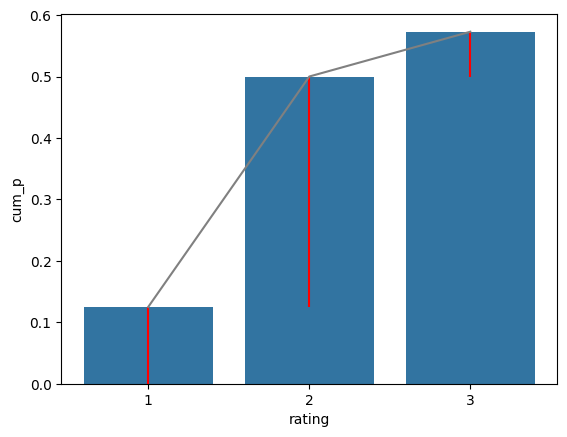

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df=pd.DataFrame({'rating':[1,2,3,4], 'cum_log_odds':cum_log_odds, 'cum_p':cum_p})
df['diff']=(df.cum_p.shift(-1)-df.cum_p).shift()
df.loc[0, 'diff']=df.loc[0, "cum_p"]

sns.barplot(df.iloc[:-1,:], x="rating", y="cum_p")
prev_min=0
for i, diff_val in enumerate(df['diff'].iloc[:-1]):
    plt.vlines(x=i, ymin=prev_min, ymax=diff_val+prev_min, color='red')
    prev_min+=diff_val

plt.plot(df['cum_p'].tolist()[:-1], color='grey')

12M3.  Can you modify the derivation of the zero-inflated Poisson distribution (ZIPoisson) from the chapter to construct a zero-inflated binomial distribution?

## 🧮 Derivation of the Zero-Inflated Binomial (ZIBinomial) Distribution

We want to model a process where:

- With probability \( \pi \), the outcome is always zero (e.g., the monk was too drunk to try).
- With probability \( 1 - \pi \), the outcome is generated from a Binomial process with parameters \( n \) and \( \theta \).

---

### ✅ 1. Binomial Likelihood Recap

$$
P(y \mid n, \theta) = \binom{n}{y} \theta^y (1 - \theta)^{n - y}
$$

---

### ✅ 2. Zero-Inflation Logic

Let:

- \( \pi \): probability of a structural zero  
- \( \theta \): probability of success in the Binomial component  
- \( n \): number of trials  

Then:

#### For \( y = 0 \):

There are two ways to observe zero:

1. Structural zero (e.g., didn’t try): probability \( \pi \)  
2. Tried but got 0 successes: \( (1 - \pi)(1 - \theta)^n \)

$$
P(y = 0 \mid n, \pi, \theta) = \pi + (1 - \pi)(1 - \theta)^n
$$

#### For \( y > 0 \):

Only from the Binomial process:

$$
P(y = k \mid n, \pi, \theta) = (1 - \pi) \cdot \binom{n}{k} \theta^k (1 - \theta)^{n - k}, \quad k > 0
$$

---

### ✅ 3. Final ZIBinomial Likelihood

$$
P(y \mid n, \pi, \theta) =
\begin{cases}
\pi + (1 - \pi)(1 - \theta)^n, & \text{if } y = 0 \\
(1 - \pi) \cdot \binom{n}{y} \theta^y (1 - \theta)^{n - y}, & \text{if } y > 0
\end{cases}
$$

---

### ✅ 4. Regression Form (GLM)

You can model both parameters with predictors:

$$
\text{logit}(\pi_i) = \alpha + \beta x_i
$$

$$
\text{logit}(\theta_i) = \gamma + \delta x_i
$$

Then:

$$
y_i \sim \text{ZIBinomial}(n_i, \pi_i, \theta_i)
$$

---

### 📦 Summary

| Parameter     | Meaning                                      |
|---------------|----------------------------------------------|
| \( \pi \)     | Probability of structural (inflated) zero    |
| \( \theta \)  | Success probability in the binomial process  |
| \( n \)       | Number of trials                             |